<a href="https://colab.research.google.com/github/Ns09844/Data-Analysis-Projects/blob/healthcare/OCD_Patient_Demographics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ocd = pd.read_csv('/content/OCD Patient Dataset_ Demographics & Clinical Data.csv')

In [ ]:
print(ocd.shape)

(1500, 17)


In [ ]:
print(ocd.columns)

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications'],
      dtype='object')


In [ ]:
ocd.head(5)

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


In [ ]:
ocd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Patient ID                     1500 non-null   int64   
 1   Age                            1500 non-null   int64   
 2   Gender                         1500 non-null   object  
 3   Ethnicity                      1500 non-null   object  
 4   Marital Status                 1500 non-null   object  
 5   Education Level                1500 non-null   object  
 6   OCD Diagnosis Date             1500 non-null   object  
 7   Duration of Symptoms (months)  1500 non-null   int64   
 8   Previous Diagnoses             1500 non-null   object  
 9   Family History of OCD          1500 non-null   object  
 10  Obsession Type                 1500 non-null   object  
 11  Compulsion Type                1500 non-null   object  
 12  Y-BOCS Score (Obsessions)      150

In [ ]:
#Checking for Na values
ocd.isna().sum()

,0
Patient ID,0
Age,0
Gender,0
Ethnicity,0
Marital Status,0
Education Level,0
OCD Diagnosis Date,0
Duration of Symptoms (months),0
Previous Diagnoses,248
Family History of OCD,0


In [ ]:
mode_previous_diagnoses = ocd['Previous Diagnoses'].mode()[0]
mode_medications = ocd['Medications'].mode()[0]

ocd['Previous Diagnoses'].fillna(mode_previous_diagnoses, inplace = True)
ocd['Medications'].fillna(mode_medications, inplace = True)

/tmp/ipython-input-738658918.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ocd['Previous Diagnoses'].fillna(mode_previous_diagnoses, inplace = True)
/tmp/ipython-input-738658918.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
ocd.isna().sum()

,0
Patient ID,0
Age,0
Gender,0
Ethnicity,0
Marital Status,0
Education Level,0
OCD Diagnosis Date,0
Duration of Symptoms (months),0
Previous Diagnoses,0
Family History of OCD,0


In [ ]:
#General statistics
ocd.describe()

,Patient ID,Age,Duration of Symptoms (months),Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions)
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,5541.254000,46.781333,121.745333,20.048000,19.62600
std,2562.389469,16.830321,67.404610,11.823884,11.78287
min,1017.000000,18.000000,6.000000,0.000000,0.00000
25%,3338.000000,32.000000,64.000000,10.000000,9.00000
50%,5539.500000,47.000000,121.000000,20.000000,20.00000
75%,7745.500000,61.000000,178.000000,31.000000,29.00000
max,9995.000000,75.000000,240.000000,40.000000,40.00000


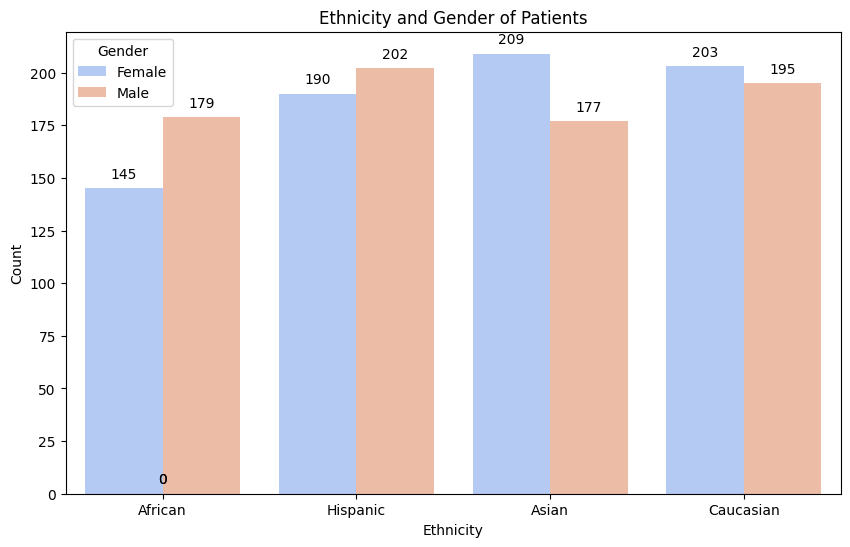

In [ ]:
#Ethnicity Visualizations

plt.figure(figsize=[10,6])
plot = sns.countplot(ocd, x = 'Ethnicity', hue = 'Gender', palette = 'coolwarm')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.title('Ethnicity and Gender of Patients')

for p in plot.patches:
    plt.annotate(format(p.get_height(), '.0f'),
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha = 'center', va = 'center',
                xytext = (0,10),
                 textcoords = 'offset points')
#Patients of Caucasian and Hispanic ethnicity make up the highest proportion

In [ ]:
#Age Group Creation

age_groups = ['{0}-{1}'.format(i, i + 9) for i in range(18, 75, 10)]
ocd['Age Group'] = pd.cut(ocd['Age'], range(18, 80, 10), labels = age_groups)

In [ ]:
ocd['Age Group'].isnull().sum()

np.int64(25)

In [ ]:
ocd['Age Group'].value_counts().sort_index()

,count
Age Group,
18-27,257
28-37,260
38-47,236
48-57,282
58-67,234
68-77,206


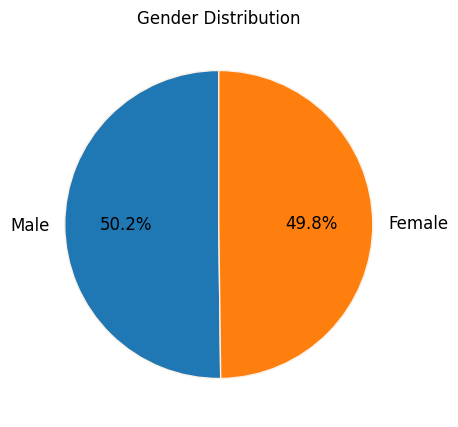

In [ ]:
#Gender
plt.figure(figsize = (8,5))

plt.pie(ocd['Gender'].value_counts(), labels = ocd['Gender'].value_counts().index,
        autopct = '%0.1f%%',
        startangle = 90,
        textprops={'fontsize':12},
        wedgeprops={'linewidth':1, 'edgecolor':'linen'})
plt.title('Gender Distribution')

plt.show()

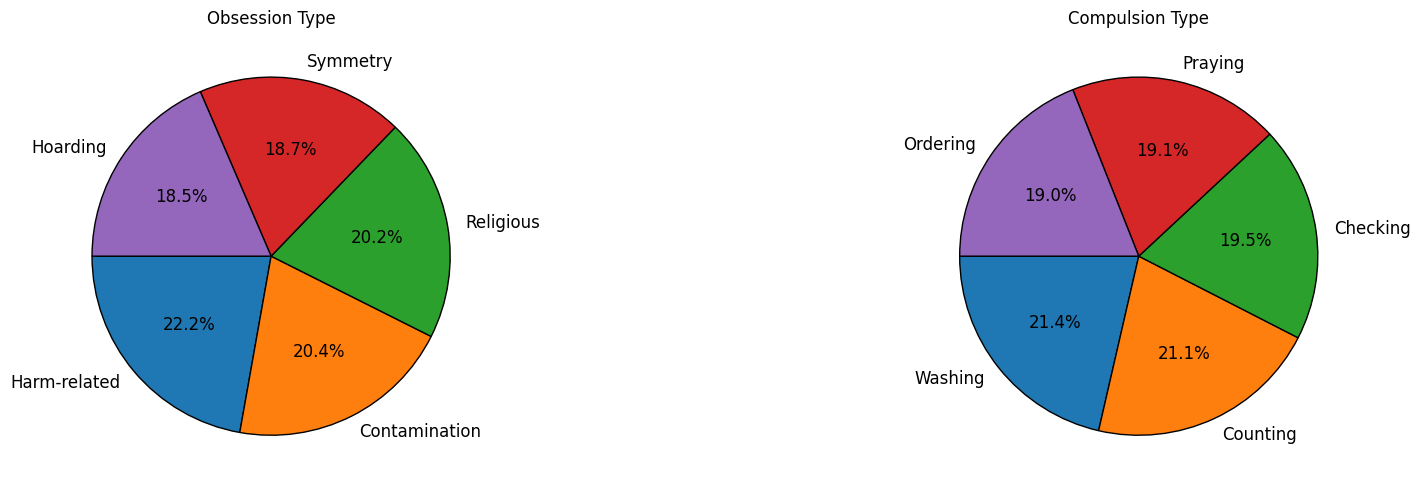

In [ ]:
#Obsessions and Compulsions subplot

plt.figure(figsize = (20,5))

plt.subplot(1,2,1)
plt.pie(ocd['Obsession Type'].value_counts(), labels = ocd['Obsession Type'].value_counts().index,
        autopct = '%0.1f%%',
        startangle = 180,
        textprops = {'fontsize':12},
        wedgeprops = {'linewidth':1, 'edgecolor':'black'})
plt.title('Obsession Type')

plt.subplot(1,2,2)
plt.pie(ocd['Compulsion Type'].value_counts(), labels = ocd['Compulsion Type'].value_counts().index,
        autopct = '%0.1f%%',
        startangle = 180,
        textprops = {'fontsize':12},
        wedgeprops = {'linewidth':1, 'edgecolor':'black'})
plt.title('Compulsion Type')
plt.tight_layout()
plt.show()

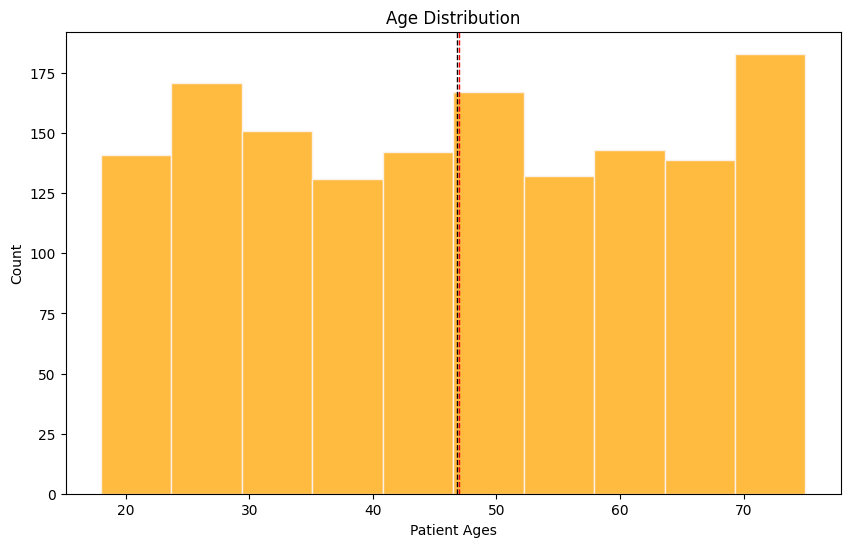

In [ ]:
#Age distribution

plt.figure(figsize = (10,6))
sns.histplot(x = 'Age', data = ocd, bins = 10, color = 'orange', edgecolor = 'linen')
plt.axvline(ocd['Age'].mean(), color='black',linestyle='dashed',linewidth=1)
plt.axvline(ocd['Age'].median(), color='red', linestyle='dashed', linewidth=1)
plt.xlabel('Patient Ages')
plt.title('Age Distribution')
plt.show()

#normal distribution

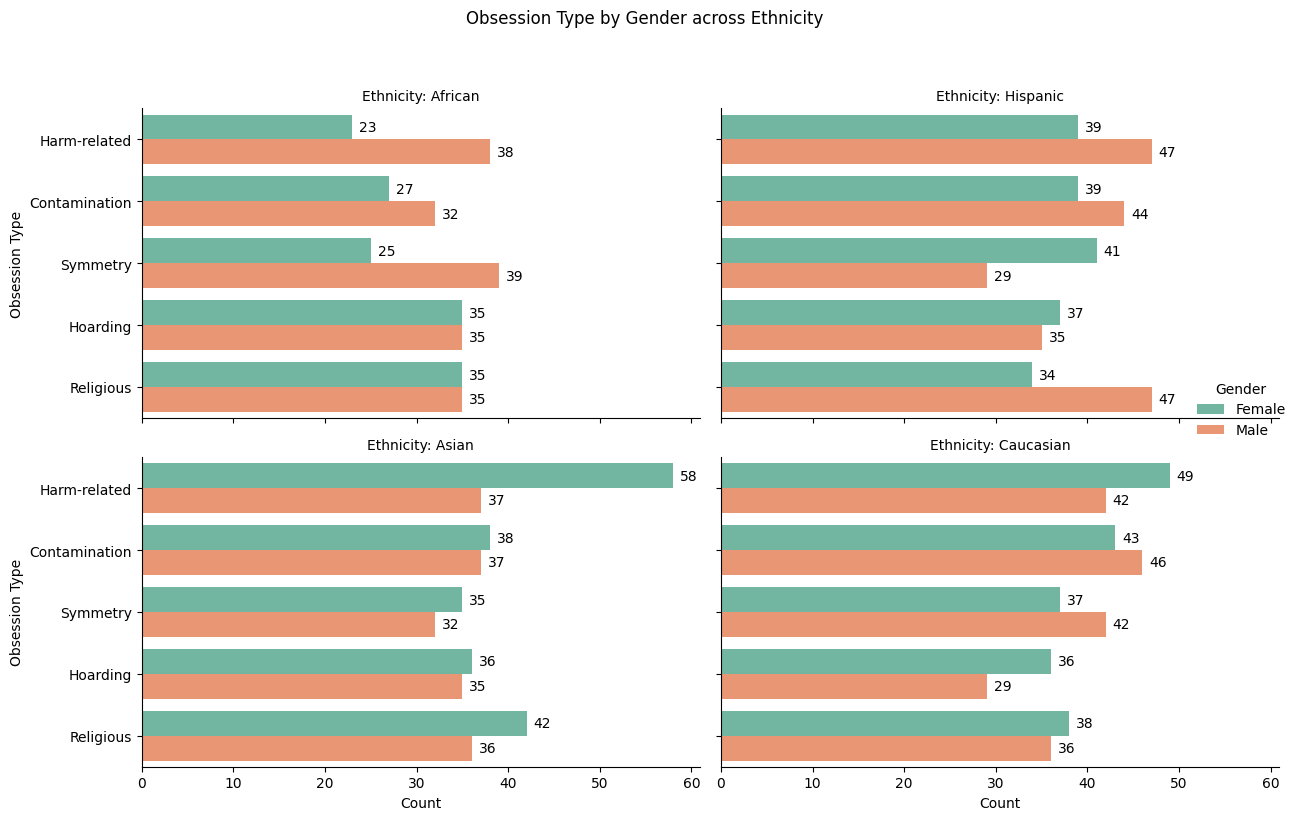

In [ ]:
#Obsession Type by Gender
plot = sns.catplot(data=ocd, y='Obsession Type', hue='Gender',
                   col = "Ethnicity", kind = "count", palette='Set2',
                   col_wrap=2, height=4, aspect=1.5)

plot.set_titles("Ethnicity: {col_name}")

plot.set_axis_labels("Count", "Obsession Type")

# Main Title
plot.fig.suptitle('Obsession Type by Gender across Ethnicity', y=1.02)

# Annotating each plot
for ax in plot.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center',
                        xytext=(5, 0),
                        textcoords='offset points')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



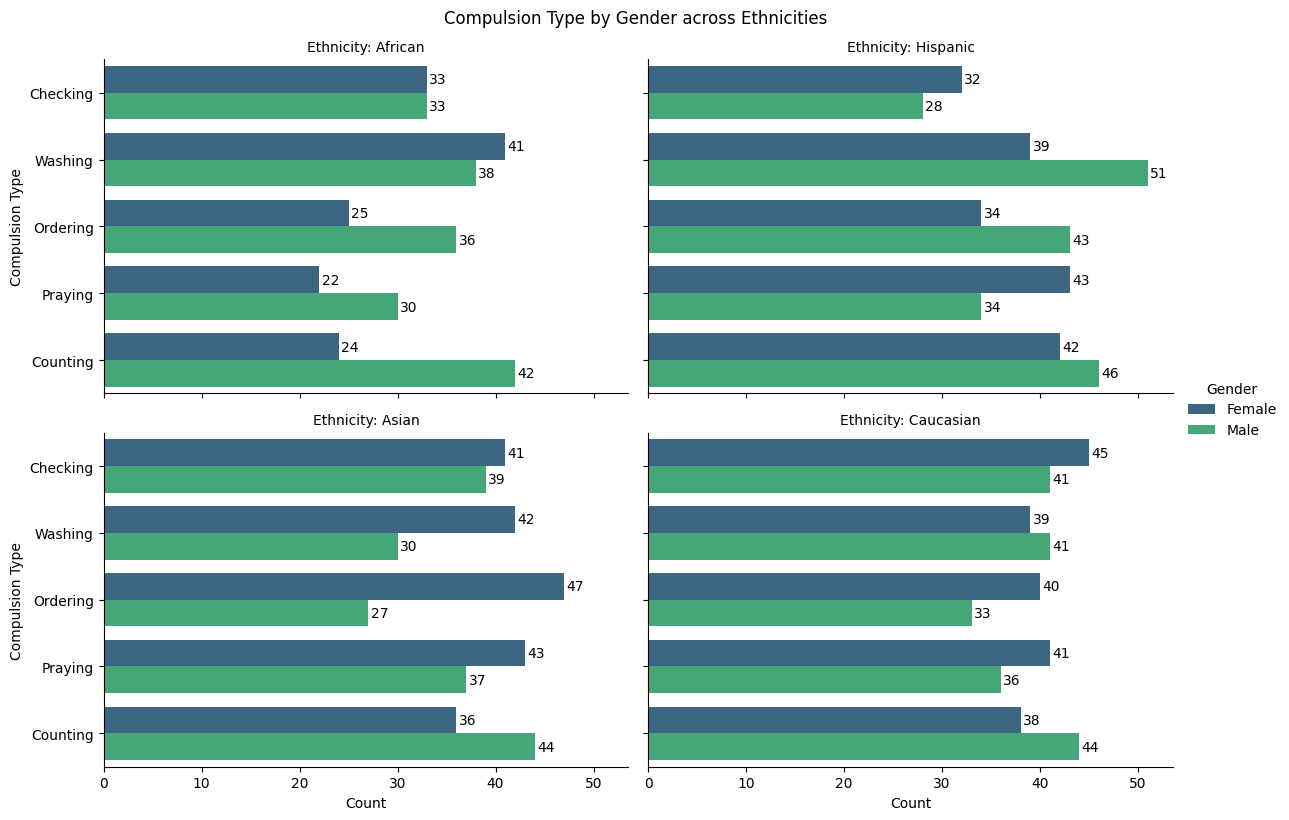

In [ ]:
#Compulsion Type by Gender across Ethnicities

plot = sns.catplot(data=ocd, y = 'Compulsion Type', col = 'Ethnicity',
                   hue='Gender', kind="count", palette="viridis",
                   col_wrap=2, height=4, aspect=1.5)

plot.set_titles("Ethnicity: {col_name}")
plot.set_axis_labels("Count", "Compulsion Type")

plot.fig.suptitle("Compulsion Type by Gender across Ethnicities", y = 1.02)

for ax in plot.axes.flat:
  for p in ax.patches:
      width = p.get_width()
      if width > 0:
       ax.annotate(format(width, '.0f'),
                  (width, p.get_y() + p.get_height()/2),
                   ha="center", va="center",
                   xytext = (8,0),
                   textcoords='offset points')


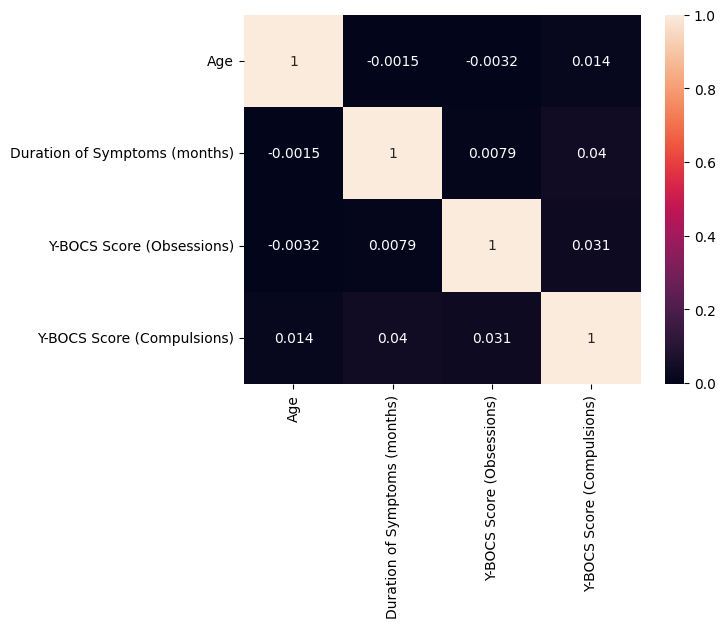

In [ ]:
#Correlation matrix

corr_matrix = ocd[['Age', 'Duration of Symptoms (months)',
                   'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']].corr()

ax = sns.heatmap(corr_matrix, annot = True)

# Conclusions


*   Gender distribution of patients almost the same, but shows variation in ethnicities like Asian and African.
*   Among African males, most common obsessions are harm related and symmetry, while hoarding and religious obsessions are the most common amongst females.


*   Harm related obsessions the most common amongst Asian and Caucasian females.
*   Counting and washing compulsions most common in African and Hispanic men respectively.


*   Ordering, washing and praying most common compulsions in Asian females.
*   Checking and praying most common compulsions in Caucasian females, counting most common in males.





